# Zaman Serisi Tahmini: Keşifsel Veri Analizine Pratik Bir Kılavuzlebilir:

#Veri

Öncelikle veri setini tanımlayalım: Bu makalenin amaçları doğrultusunda, Kaggle'ın Saatlik Enerji Tüketimi verilerini alacağız . Bu veri seti, ABD'deki bölgesel bir iletim organizasyonu olan PJM Saatlik Enerji Tüketimi verileriyle ilgilidir.

Saatlik güç tüketim verileri PJM'nin internet sitesinden alınmış olup megawatt (MW) cinsindendir.

#Keşifsel Veri Analizi
Şimdi zaman serileri ile çalışırken hangi analizlerin yapılması gerektiğini tanımlayalım.

Elbette, en önemli şeylerden biri verileri çizmektir: grafikler, desenler, alışılmadık gözlemler, zaman içindeki değişimler ve değişkenler arasındaki ilişkiler gibi birçok özelliği vurgulayabilir. 

## 1.Tanımlayıcı İstatistikler

In [1]:
import pandas as pd
##Kendi blgisayarımda sıralı hale getirdiğim verilerimi çağırıyorum. 

#Yükleme ve ön işleme adımları
df = pd.read_csv('PJM(AEP)_energy_dataset_yıl_ay_guneklemeliiiii.csv')
df = df.set_index( 'Datetime' ) 
df.index = pd.to_datetime(df.index) 

df.describe()

,PJME_MW,year,month,day
count,145362.000000,145392.000000,145392.000000,145392.000000
mean,32080.511310,2009.800704,6.435836,15.722529
std,6463.863785,4.791740,3.438967,8.801313
min,14544.000000,2002.000000,1.000000,1.000000
25%,27573.000000,2006.000000,3.000000,8.000000
50%,31421.000000,2010.000000,6.000000,16.000000
75%,35650.000000,2014.000000,9.000000,23.000000
max,62009.000000,2018.000000,12.000000,31.000000


In [2]:
df.drop('year', inplace=True, axis=1)  #listeden çıkaramadığım aa bb cc dd sütunlarını siliyorum
df.drop('month', inplace=True, axis=1)
df.drop('day', inplace=True, axis=1)
df.drop('hour', inplace=True, axis=1)
df.describe()

,PJME_MW
count,145362.000000
mean,32080.511310
std,6463.863785
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [3]:
# Eksik veriler  #her sütunda kaç tane boş değer olduğunu kontrol etme
df.isna().sum()

PJME_MW    30
dtype: int64

In [4]:
df['PJME_MW'].fillna(df['PJME_MW'].median(), inplace=True)  #bu boşlukları medyanla dolduralım. #df = df.dropna() komutu ile NaN değerlerine sahip tüm satırları silebilirizde.

In [5]:
# Eksik veriler  #her sütunda kaç tane boş değer olduğunu kontrol etme
df.isna().sum()

PJME_MW    0
dtype: int64

## 2.Zaman çizelgesi
Başlamak için bariz grafik zaman çizelgesidir. Yani, gözlemler gözlemlendikleri zamana göre çizilir
ve ardışık gözlemler çizgilerle birleştirilir.

Python'da Pandas ve Matplotlib'i kullanabiliriz:

C:\Users\yusuf\AppData\Local\Temp\ipykernel_5376\3041400496.py:4: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn")


Text(0.5, 0, 'Date')

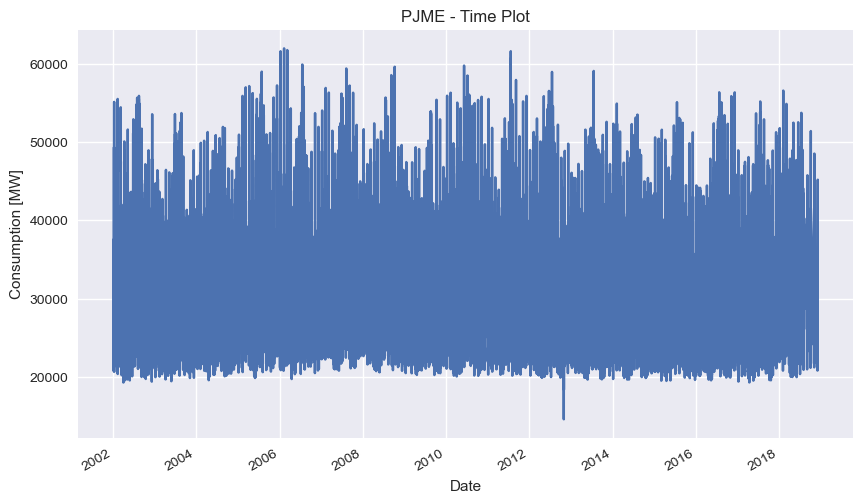

In [6]:
import matplotlib.pyplot as plt

#Pyplot stilini ayarla 
plt.style.use("seaborn")

#Plot
df['PJME_MW'].plot(title='PJME - Time Plot', figsize=(10,6))
plt.ylabel('Consumption [MW]')
plt.xlabel('Date')  #verilerin sırası eklemeli değerlere göre farklı oyuzden alttaki grafik farklı çıkıyor.hemde eksik değerler var

## 3.Mevsimsel Arsalar
Mevsimsel grafik, temelde verilerin ait oldukları serinin bireysel "mevsimlerine" göre çizildiği bir zaman grafiğidir.

In [8]:
# Zorunlu alanları tanımlama Raminin satırları farklı sonuç aynı
df['year'] = [x for x in df.index.year]
df['month'] = [x for x in df.index.month]
df = df.reset_index()
df['week'] = df['Datetime'].apply(lambda x:x.week)
df = df.set_index('Datetime')
df['hour'] = [x for x in df.index.hour]
df['day'] = [x for x in df.index.day_of_week]

## 3.1Mevsimsel grafik — Yıllık tüketim
Enerji tüketiminin yıllara göre aylara göre gruplandırılmasını ifade eden grafik oldukça ilgi çekicidir; bu, yıllık mevsimselliği vurgular ve bize yıllar içindeki artan/azalan eğilimler hakkında bilgi verebilir.

In [9]:
df['day_str'] = [x.strftime('%a') for x in df.index]
df['year_month'] = [str(x.year) + '_' + str(x.month) for x in df.index]

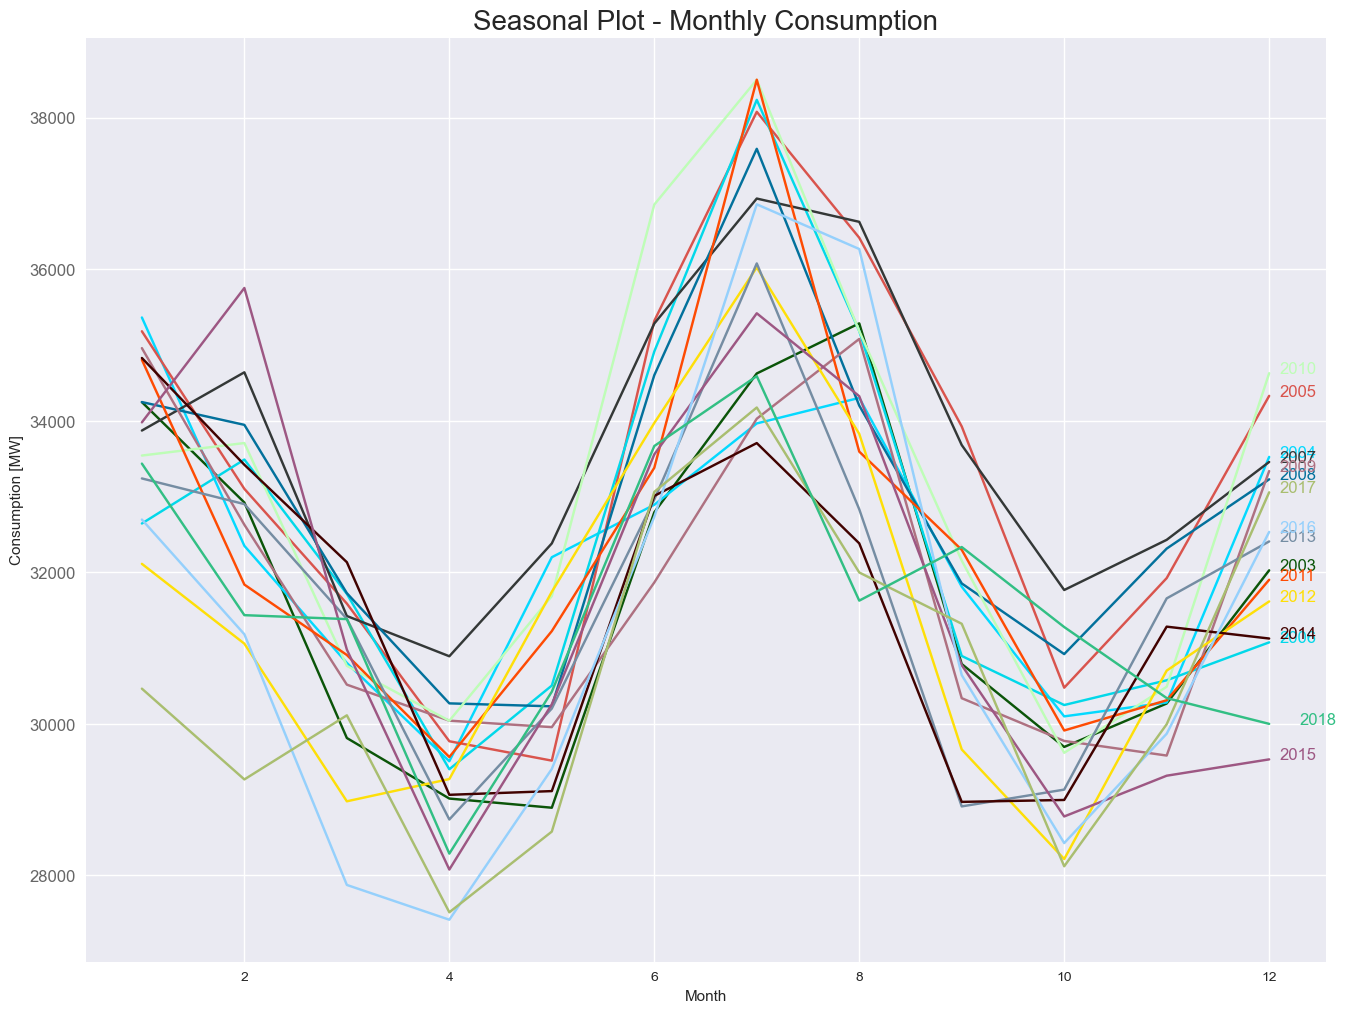

In [10]:
import numpy as np
import matplotlib as mpl

# Renk paletini tanımlama
np.random.seed(42)
df_plot = df[['month', 'year', 'PJME_MW']].dropna().groupby(['month', 'year']).mean()[['PJME_MW']].reset_index()
years = df_plot['year'].unique()
colors = np.random.choice(list(mpl.colors.XKCD_COLORS.keys()), len(years), replace=False)

# Plot(Grafik)
plt.figure(figsize=(16,12))
for i, y in enumerate(years):
    if i > 0:        
        plt.plot('month', 'PJME_MW', data=df_plot[df_plot['year'] == y], color=colors[i], label=y)
        if y == 2018:
            plt.text(df_plot.loc[df_plot.year==y, :].shape[0]+0.3, df_plot.loc[df_plot.year==y, 'PJME_MW'][-1:].values[0], y, fontsize=12, color=colors[i])
        else:
            plt.text(df_plot.loc[df_plot.year==y, :].shape[0]+0.1, df_plot.loc[df_plot.year==y, 'PJME_MW'][-1:].values[0], y, fontsize=12, color=colors[i])

# Setting labels(Etiketleri ayarlama)
plt.gca().set(ylabel= 'PJME_MW', xlabel = 'Month')
plt.yticks(fontsize=12, alpha=.7)
plt.title("Seasonal Plot - Monthly Consumption", fontsize=20)  #Mevsimsel Çizim - Aylık Tüketim
plt.ylabel('Consumption [MW]')
plt.xlabel('Month')
plt.show()

## 3.2Mevsimsel grafik — Haftalık tüketim

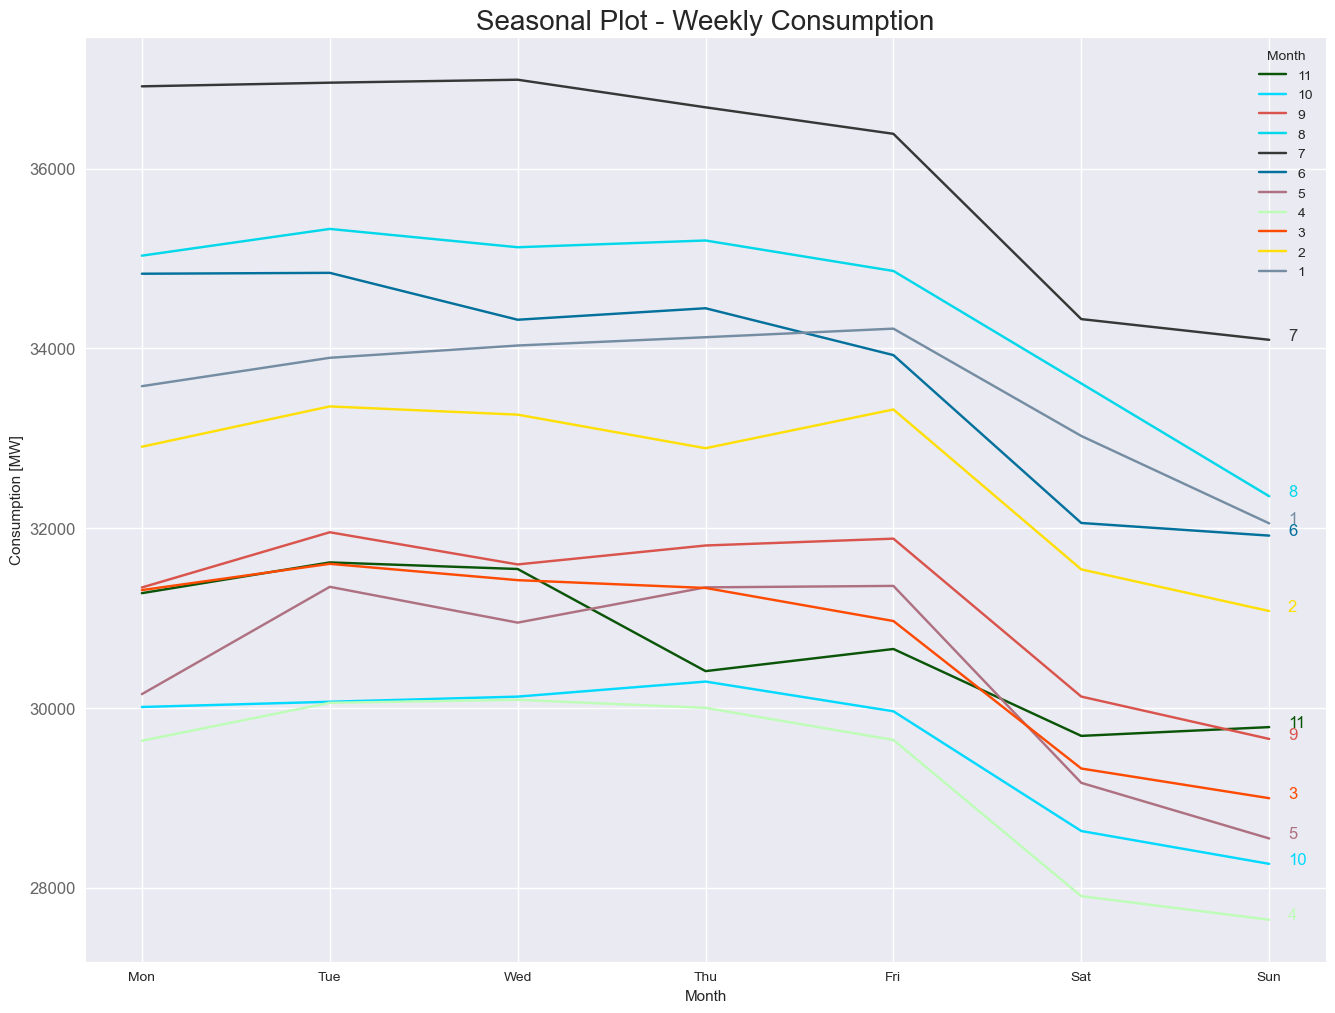

In [12]:
# Renk paletini tanımlama
np.random.seed(42)
df_plot = df[['month', 'day_str', 'PJME_MW', 'day']].dropna().groupby(['day_str', 'month', 'day']).mean()[['PJME_MW']].reset_index()
df_plot = df_plot.sort_values(by='day', ascending=True)

# Renk paletini tanımlama #colors u Raminden farklı
months = df_plot['month'].unique()
colors = np.random.choice(list(mpl.colors.XKCD_COLORS.keys()), len(months), replace=False)

# Plot
plt.figure(figsize=(16,12))
for i, y in enumerate(months):
    if i > 0:        
        plt.plot('day_str', 'PJME_MW', data=df_plot[df_plot['month'] == y], color=colors[i], label=y)
        if y == 2018:
            plt.text(df_plot.loc[df_plot.month==y, :].shape[0]-.9, df_plot.loc[df_plot.month==y, 'PJME_MW'][-1:].values[0], y, fontsize=12, color=colors[i])
        else:
            plt.text(df_plot.loc[df_plot.month==y, :].shape[0]-.9, df_plot.loc[df_plot.month==y, 'PJME_MW'][-1:].values[0], y, fontsize=12, color=colors[i])


# Etiketleri Ayarlama
plt.gca().set(ylabel= 'PJME_MW', xlabel = 'Month')
plt.yticks(fontsize=12, alpha=.7)
plt.title("Seasonal Plot - Weekly Consumption", fontsize=20)
plt.ylabel('Consumption [MW]')
plt.xlabel('Month')
plt.legend(title='Month')  #sonradan ekledim sağ üstteki montlar için
plt.show()

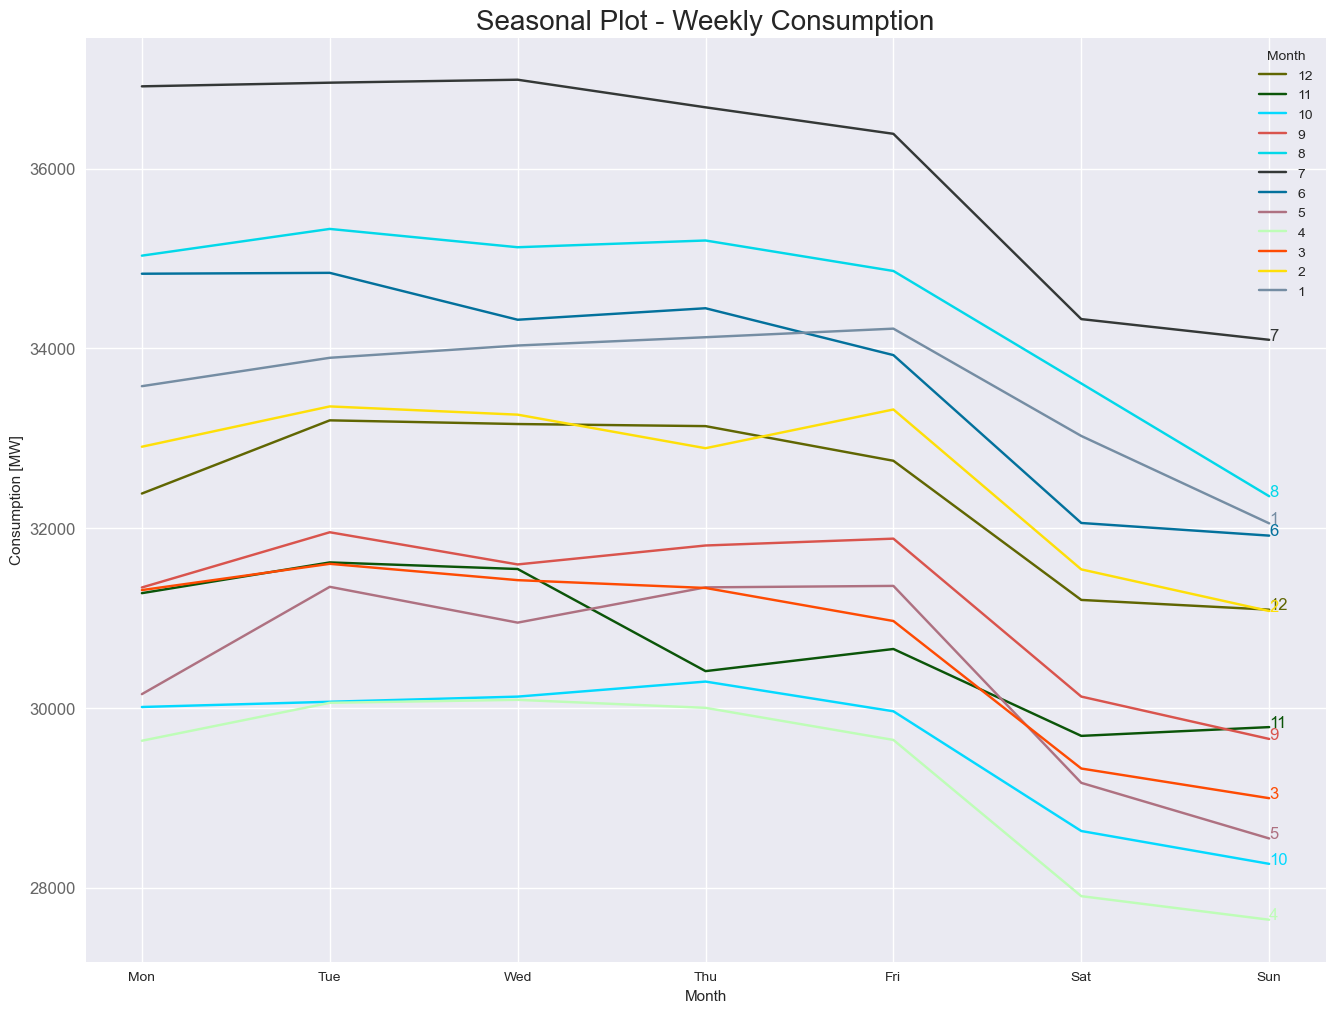

In [13]:
# Renk paletini tanımlama  ##bu kısımda ramin in plot kısmını aldım ve üstte çıkmayan 12. ay çıktı.
np.random.seed(42)
df_plot = df[['month', 'day_str', 'PJME_MW', 'day']].dropna().groupby(['day_str', 'month', 'day']).mean()[['PJME_MW']].reset_index()
df_plot = df_plot.sort_values(by='day', ascending=True)

# Renk paletini tanımlama #colors u Raminden farklı
months = df_plot['month'].unique()
colors = np.random.choice(list(mpl.colors.XKCD_COLORS.keys()), len(months), replace=False)

# Plot
plt.figure(figsize=(16, 12))  
for i, month in enumerate(months):
    month_data = df_plot[df_plot['month'] == month]
    plt.plot(month_data['day_str'], month_data['PJME_MW'], color=colors[i], label=month)
    plt.text(len(month_data['day_str']) - 1, month_data['PJME_MW'].iloc[-1], month, fontsize=12, color=colors[i])


# Etiketleri Ayarlama
plt.gca().set(ylabel= 'PJME_MW', xlabel = 'Month')
plt.yticks(fontsize=12, alpha=.7)
plt.title("Seasonal Plot - Weekly Consumption", fontsize=20)
plt.ylabel('Consumption [MW]')
plt.xlabel('Month')
plt.legend(title='Month')
plt.show()

## 3.3Mevsimsel grafik — Günlük tüketim

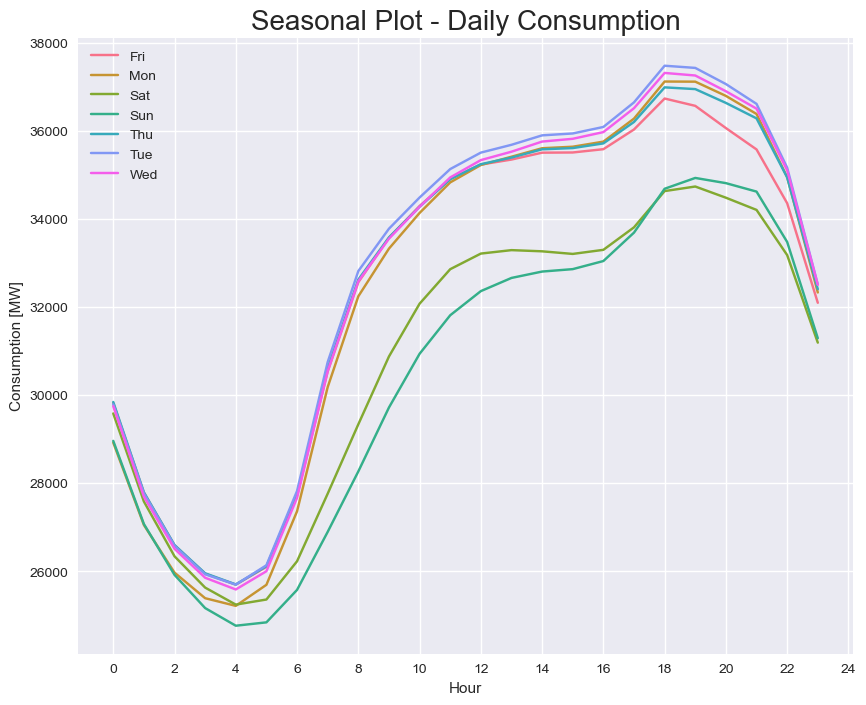

In [14]:
import seaborn as sns

# Defining the dataframe
df_plot = df[['hour', 'day_str', 'PJME_MW']].dropna().groupby(['hour', 'day_str']).mean()[['PJME_MW']].reset_index()

# Plot using Seaborn
plt.figure(figsize=(10,8))
sns.lineplot(data = df_plot, x='hour', y='PJME_MW', hue='day_str', legend=True)
plt.locator_params(axis='x', nbins=24)
plt.title("Seasonal Plot - Daily Consumption", fontsize=20)
plt.ylabel('Consumption [MW]')
plt.xlabel('Hour')
plt.legend()  #burdaki grafik ölçekli kağıda diğeri beyaz yuzeye

## 3.4Mevsimsel çizim — Özellik Mühendisliği

## 4.Kutu Grafikleri

## 4.1Kutu Grafikleri — Toplam tüketim
Öncelikle toplam tüketime ilişkin kutu grafiğini hesaplayalım; bu Seaborn ile kolayca yapılabilir :

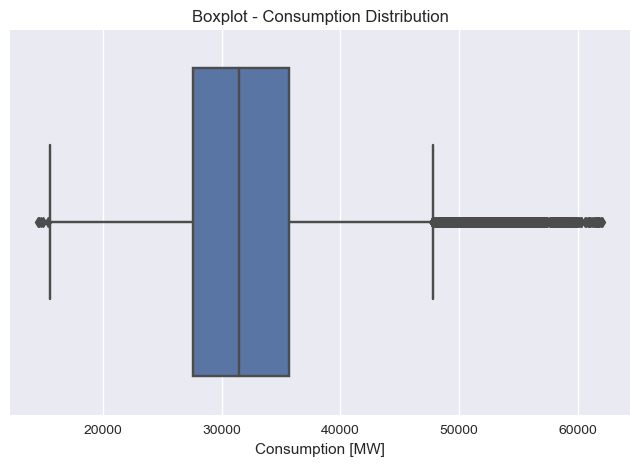

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='PJME_MW')
plt.xlabel('Consumption [MW]')
plt.title(f'Boxplot - Consumption Distribution');

## 4.2Kutu Grafikleri — Gün ay dağılımı
Çok ilginç bir grafik gün/ay kutu grafiğidir. Bir "gün ay" değişkeni oluşturularak ve tüketimler buna göre gruplandırılarak elde edilir. İşte yalnızca 2017 yılından referans alan kod:

Text(0.5, 0, 'Year Month')

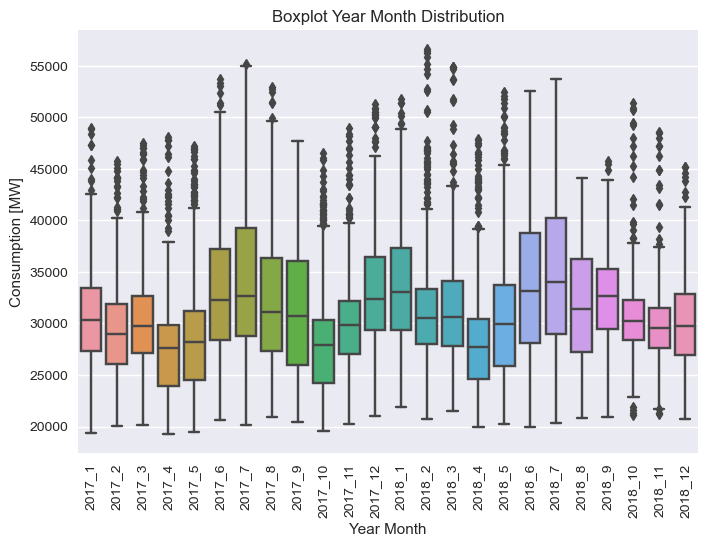

In [18]:
df['year'] = [x for x in df.index.year]
df['month'] = [x for x in df.index.month]
df['year_month'] = [str(x.year) + '_' + str(x.month) for x in df.index]

df_plot = df[df['year'] >= 2017].reset_index().sort_values(by='Datetime').set_index('Datetime')
plt.title(f'Boxplot Year Month Distribution');
plt.xticks(rotation=90)
plt.xlabel('Year Month')
plt.ylabel('MW')

sns.boxplot(x='year_month', y='PJME_MW', data=df_plot)
plt.ylabel('Consumption [MW]')
plt.xlabel('Year Month')

## 4.3Kutu Grafikleri — Gün dağılımı
Haftalık tüketim dağılımını gösteren grafik de faydalı bir grafiktir; haftalık tüketim mevsimsel grafiğine benzer.

Text(0.5, 0, 'Day of week')

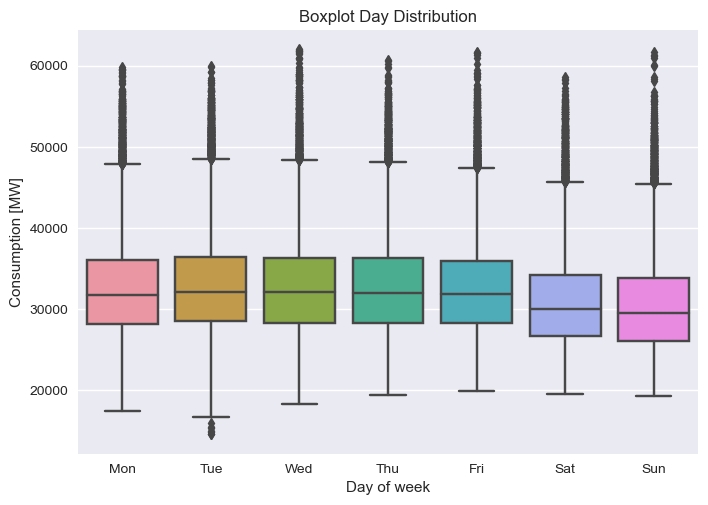

In [20]:
df_plot = df[['day_str', 'day', 'PJME_MW']].sort_values(by='day')
plt.title(f'Boxplot Day Distribution')
plt.xlabel('Day of week')
plt.ylabel('MW')
sns.boxplot(x='day_str', y='PJME_MW', data=df_plot)
plt.ylabel('Consumption [MW]')
plt.xlabel('Day of week')

## 4.4Kutu Grafikleri — Saat dağılımı
Son olarak saat dağılım kutu grafiğine bakalım. Günlük tüketim mevsimsel grafiğine benzerdir çünkü tüketimlerin gün boyunca nasıl dağıtıldığını gösterir. Aşağıda, kod:

Text(0.5, 0, 'Hour')

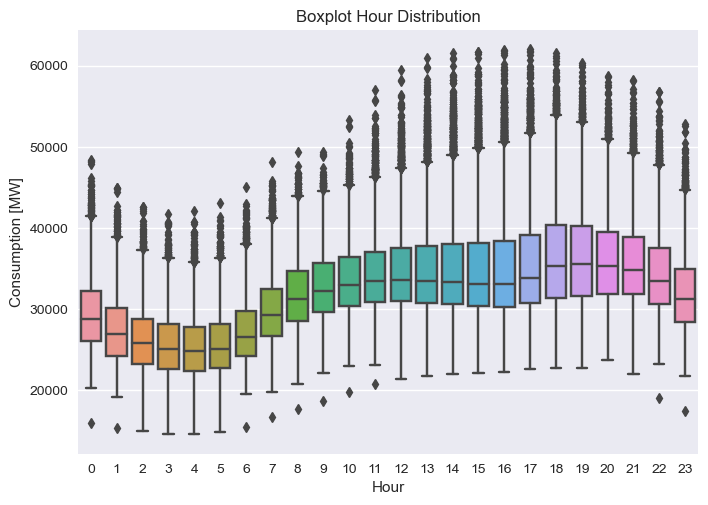

In [22]:
plt.title(f'Boxplot Hour Distribution');
plt.xlabel('Hour')
plt.ylabel('MW')
sns.boxplot(x='hour', y='PJME_MW', data=df)
plt.ylabel('Consumption [MW]')
plt.xlabel('Hour')

## 5.Zaman Serisi Ayrıştırması

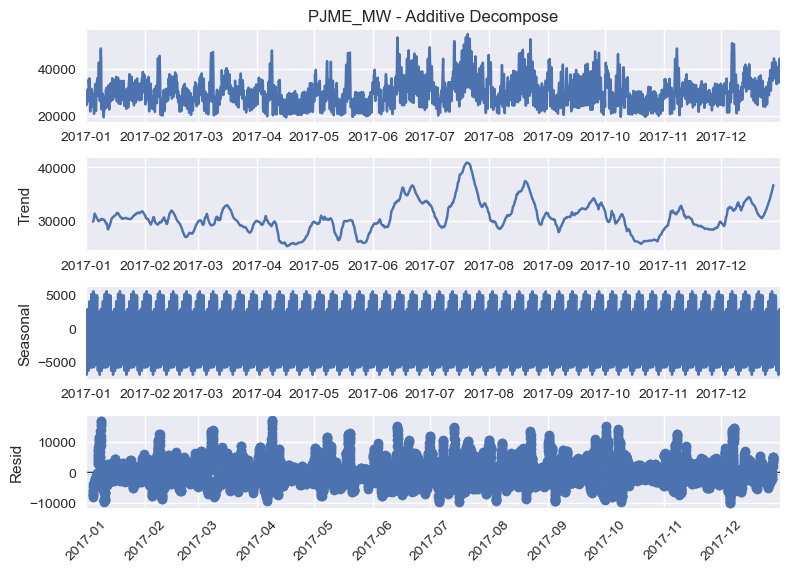

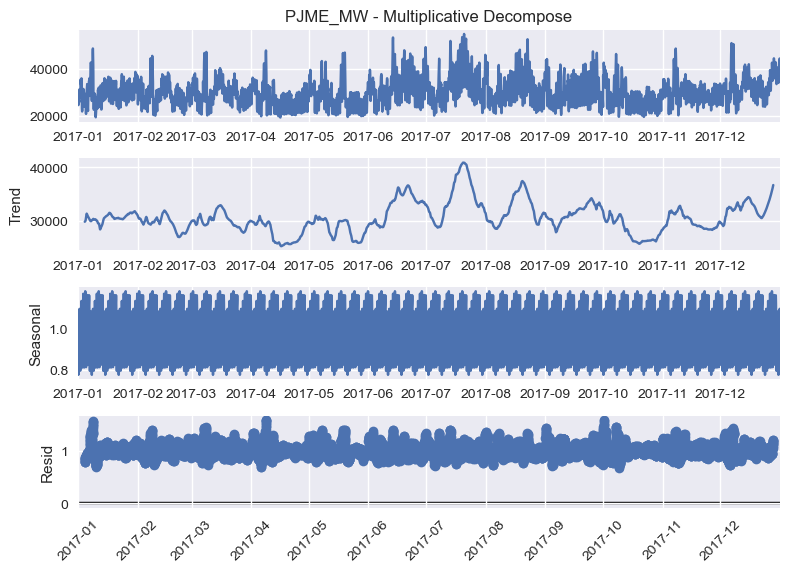

In [24]:
#İlgili modülü içe aktarma
from statsmodels.tsa.seasonal import seasonal_decompose

# 2017 yılı için verileri filtreleme ve dizini sıfırlama
df_plot = df[df['year'] == 2017].reset_index()

# Yinelenen Datetime girişlerini kaldırma ve Datetime'a göre sıralama
df_plot = df_plot.drop_duplicates(subset=['Datetime']).sort_values(by='Datetime')

# Datetime sütununu dizin olarak ayarlama
df_plot = df_plot.set_index('Datetime')

# Hem eklemeli hem de çarpmalı ayrıştırma için 'PJME_MW' sütununu kopyalama
df_plot['PJME_MW - Multiplicative Decompose'] = df_plot['PJME_MW']  #Çarpımsal Ayrıştırma
df_plot['PJME_MW - Additive Decompose'] = df_plot['PJME_MW']        #Eklemeli Ayrıştırma

# Eklemeli ayrıştırma gerçekleştirme
result_add = seasonal_decompose(df_plot['PJME_MW - Additive Decompose'], model='additive', period=24*7)

# Çarpımsal ayrıştırma gerçekleştirme
result_mul = seasonal_decompose(df_plot['PJME_MW - Multiplicative Decompose'], model='multiplicative', period=24*7)

# Eklemeli ayrıştırma çizme
result_add.plot().suptitle('', fontsize=22)
plt.xticks(rotation=45)

# Çarpımsal ayrıştırma çizme
result_mul.plot().suptitle('', fontsize=22)
plt.xticks(rotation=45)

# Grafikleri görüntüleme
plt.show()

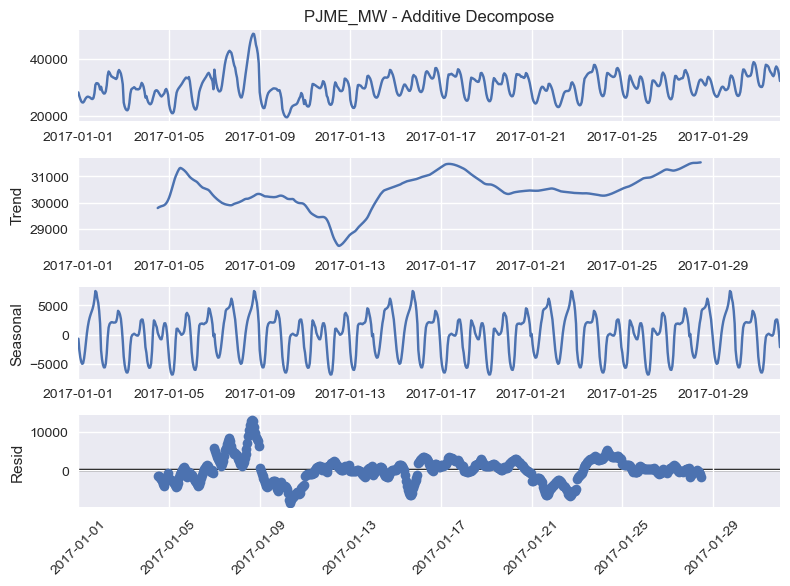

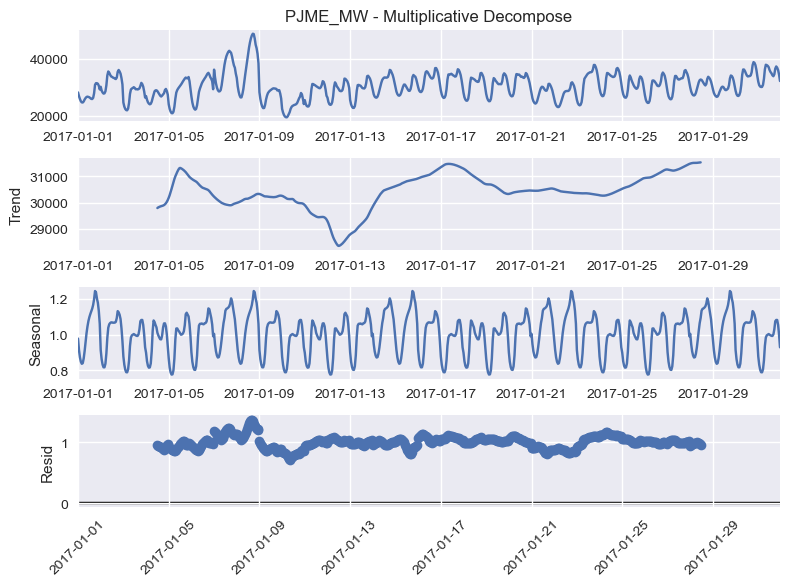

In [26]:
# 2017 yılı için verileri filtrele ve endeksi sıfırla
df_plot = df[(df['year'] == 2017)].reset_index()

# Ocak ayı için verileri filtrele
df_plot = df_plot[df_plot['month'] == 1]

# Hem eklemeli hem de çarpmalı ayrıştırma için 'PJME_MW' sütununu kopyala
df_plot['PJME_MW - Multiplicative Decompose'] = df_plot['PJME_MW']  #Çarpımsal Ayrıştırma
df_plot['PJME_MW - Additive Decompose'] = df_plot['PJME_MW']        #Eklemeli Ayrıştırma

# Yinelenen Datetime girişlerini kaldır ve Datetime'e göre sırala
df_plot = df_plot.drop_duplicates(subset=['Datetime']).sort_values(by='Datetime')

# Datetime sütununu endeks olarak ayarla
df_plot = df_plot.set_index('Datetime')

# Eklemeli ayrıştırmayı gerçekleştir
result_add = seasonal_decompose(df_plot['PJME_MW - Additive Decompose'], model='additive', period=24*7)

# Çarpımsal ayrıştırmayı gerçekleştir
result_mul = seasonal_decompose(df_plot['PJME_MW - Multiplicative Decompose'], model='multiplicative', period=24*7)

# Eklemeli ayrıştırmayı çiz
result_add.plot().suptitle('', fontsize=22)
plt.xticks(rotation=45)

# Çarpımsal ayrıştırmayı çiz
result_mul.plot().suptitle('', fontsize=22)
plt.xticks(rotation=45)

# Grafikleri görüntüle
plt.show()  #eğilim-mevsimsel-ikamet grafikleri. mevsimsel olan güne denk geliyor

## 6.Gecikme Analizi

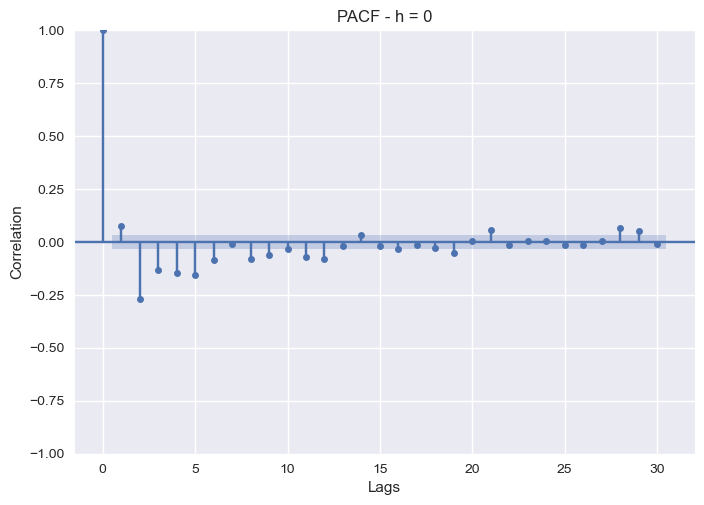

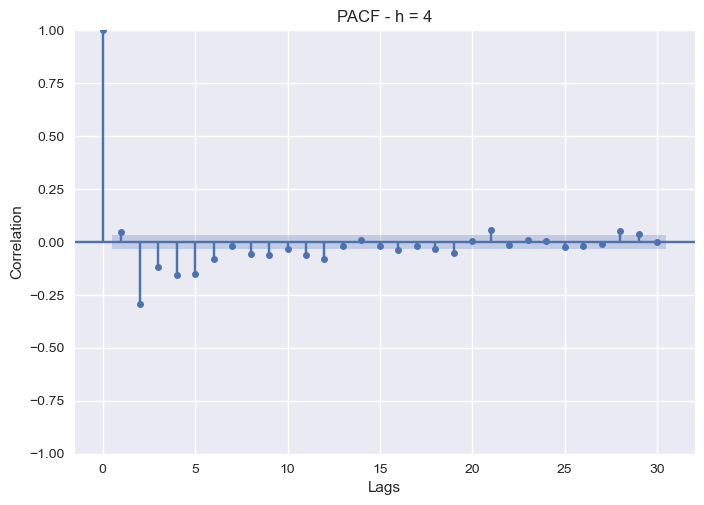

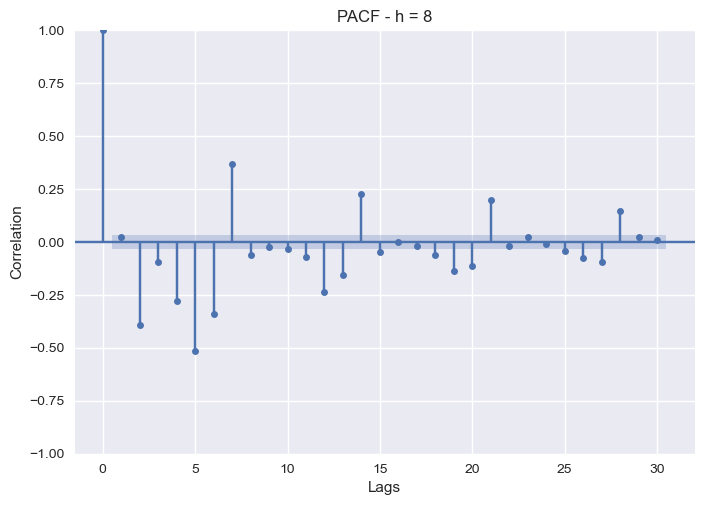

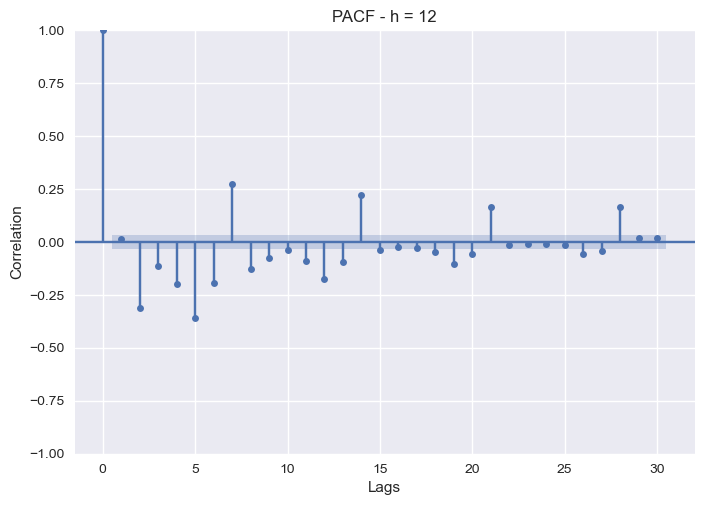

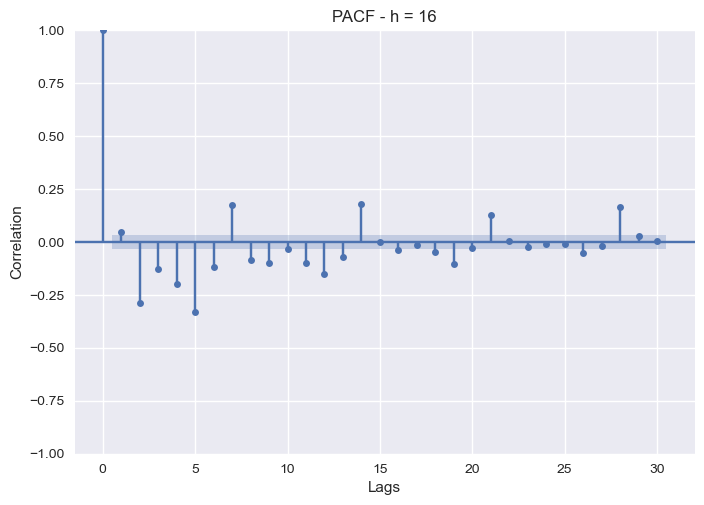

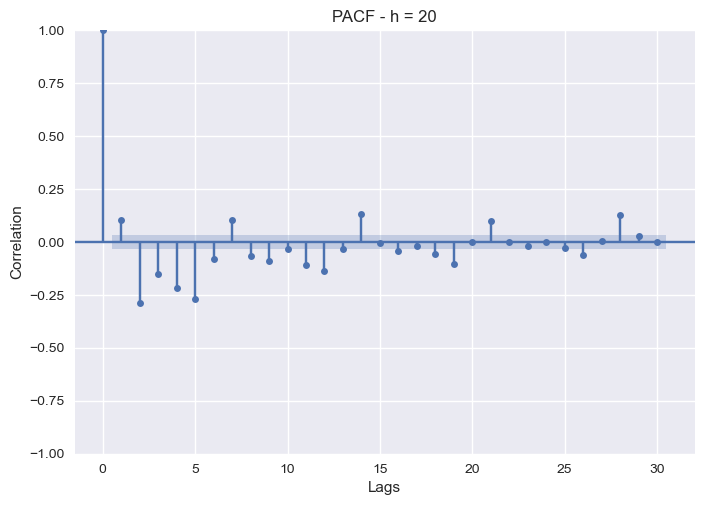

In [27]:
import warnings  #eksikti ben ekledim
warnings.filterwarnings("ignore")

from statsmodels.graphics.tsaplots import plot_pacf

actual = df['PJME_MW']
hours = range(0, 24, 4)

for hour in hours:
    plot_pacf(actual[actual.index.hour == hour].diff().dropna(), lags=30, alpha=0.01)  #pacf=Partial Autocorrelation
    plt.title(f'PACF - h = {hour}')  #kısmi otokorelasyon  #'Partial Autocorrelation - Hour {hour}' ta yazılabilir
    plt.ylabel('Correlation')   #korelasyon
    plt.xlabel('Lags')          #gecikmeler
    plt.show() 

## 6.1Gecikme analizi — Özellik Mühendisliği

In [29]:
# Uygulama ve Deneysel sonuçlar
##Bu çekirdekte analiz için Aotizhongxin veri kümesini (yüklediklerim arasında ilk veri kümesi) kullanacağım. Tüm diziler ve listeler için yalnızca ilk 5 girdinin çıktılarını yazdıracağım, aksi takdirde bir sonraki hücreye ulaşmak için çok fazla kaydırmanız gerekecek ve ayrıca işlemek de çok zaman alacak.
##Tüm girdileri yazdırmak istiyorsanız, bu çekirdeği çatallandırabilir ve dizinin veya listenin uzunluğuna kadar bir döngü çalıştırabilir ve tüm girdileri yazdırabilirsiniz.

# PAKETLER
import os
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score, max_error, explained_variance_score
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from datetime import datetime

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, ELU, LeakyReLU, PReLU
from tensorflow.keras.layers import LSTM, GRU, SimpleRNN, TimeDistributed, Bidirectional, ConvLSTM2D, Dropout
from tensorflow.keras.models import model_from_json

In [30]:
df.info()  # sütunlar hakkında bilgi ve hangi tipte veri. 

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145392 entries, 2002-01-01 01:00:00 to 2018-03-08 00:00:00
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   PJME_MW     145392 non-null  float64
 1   year        145392 non-null  int64  
 2   month       145392 non-null  int64  
 3   week        145392 non-null  int64  
 4   hour        145392 non-null  int64  
 5   day         145392 non-null  int64  
 6   day_str     145392 non-null  object 
 7   year_month  145392 non-null  object 
dtypes: float64(1), int64(5), object(2)
memory usage: 10.0+ MB


In [31]:
df.head()

,PJME_MW,year,month,week,hour,day,day_str,year_month
Datetime,,,,,,,,
2002-01-01 01:00:00,30393.0,2002,1,1,1,1,Tue,2002_1
2002-01-01 02:00:00,29265.0,2002,1,1,2,1,Tue,2002_1
2002-01-01 03:00:00,28357.0,2002,1,1,3,1,Tue,2002_1
2002-01-01 04:00:00,27899.0,2002,1,1,4,1,Tue,2002_1
2002-01-01 05:00:00,28057.0,2002,1,1,5,1,Tue,2002_1


In [32]:
df.describe()  #sütunlar hakkında istatistiksel bilgiler

,PJME_MW,year,month,week,hour,day
count,145392.000000,145392.000000,145392.00000,145392.000000,145392.00000,145392.000000
mean,32080.375227,2009.800704,6.46832,26.354799,11.50000,2.999849
std,6463.203815,4.791740,3.44389,15.029115,6.92221,1.999876
min,14544.000000,2002.000000,1.00000,1.000000,0.00000,0.000000
25%,27574.750000,2006.000000,3.00000,13.000000,5.75000,1.000000
50%,31421.000000,2010.000000,6.00000,26.000000,11.50000,3.000000
75%,35647.000000,2014.000000,9.00000,39.000000,17.25000,5.000000
max,62009.000000,2018.000000,12.00000,53.000000,23.00000,6.000000


In [35]:
print(df)

                     PJME_MW  year  month  week  hour  day day_str year_month
Datetime                                                                     
2002-01-01 01:00:00  30393.0  2002      1     1     1    1     Tue     2002_1
2002-01-01 02:00:00  29265.0  2002      1     1     2    1     Tue     2002_1
2002-01-01 03:00:00  28357.0  2002      1     1     3    1     Tue     2002_1
2002-01-01 04:00:00  27899.0  2002      1     1     4    1     Tue     2002_1
2002-01-01 05:00:00  28057.0  2002      1     1     5    1     Tue     2002_1
...                      ...   ...    ...   ...   ...  ...     ...        ...
2018-02-08 20:00:00  44057.0  2018      2     6    20    3     Thu     2018_2
2018-02-08 21:00:00  43256.0  2018      2     6    21    3     Thu     2018_2
2018-02-08 22:00:00  41552.0  2018      2     6    22    3     Thu     2018_2
2018-02-08 23:00:00  38500.0  2018      2     6    23    3     Thu     2018_2
2018-03-08 00:00:00  35486.0  2018      3    10     0    3     T

In [38]:
# veri setinin yeni halinin kaydedilmesi. artık veri setimizi bir zaman serisi olarak kaydedttik.
df.to_csv('cleaned_data.csv', index=False) #benim fikrim:index false olunca sabit kalacak indexleri karıştırmıyacak. zaman serisi çünkü.

In [39]:
# günlük ve haftalık grafikler--değerleri günlük ve haftalık olarak kaydettik
df_daily = df.resample('D').mean()  #günlük değerleri baz alıp mean-ort max min değerlerini alabiliriz. burda ort alındı.
df_weekly = df_daily.resample('W').mean() #haftalık değerleri baz alıp mean-ort max min değerlerini alabiliriz. burda ort alındı.

<AxesSubplot: xlabel='Datetime', ylabel='PJME_MW'>

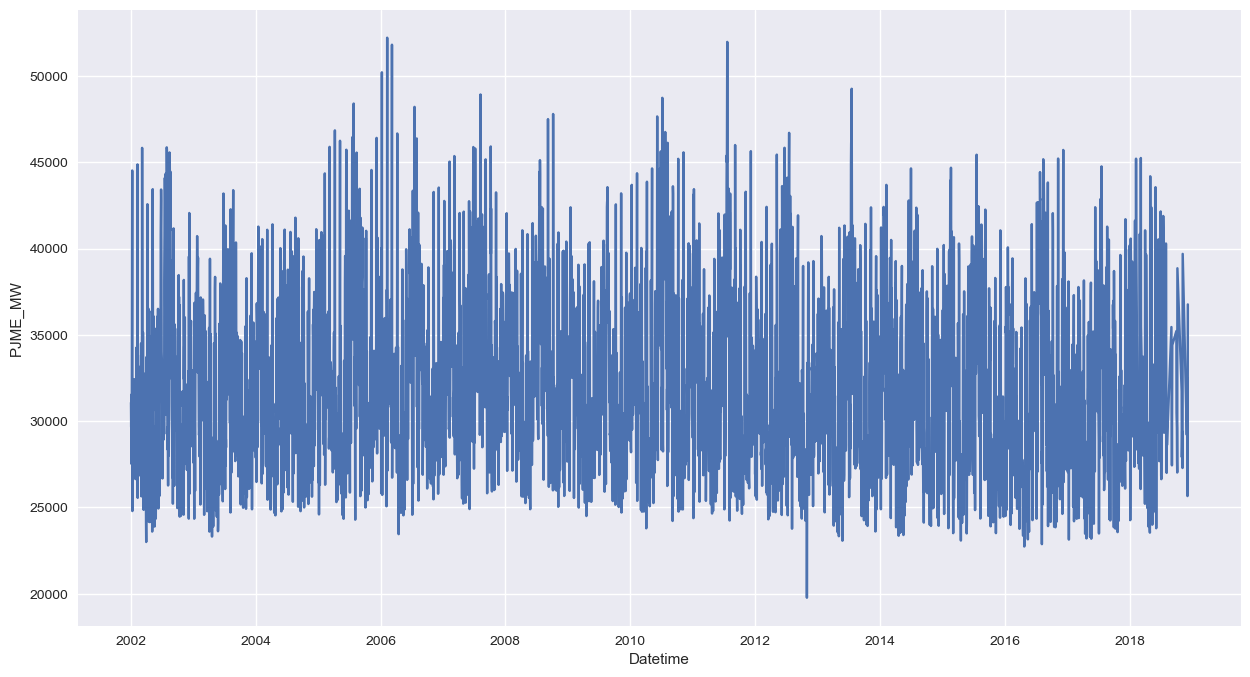

In [40]:
plt.figure(figsize=(15,8)) #günlük olarak PJME değerlerinin nasıl göründüğüne bakalım.
sns.lineplot(y="PJME_MW" ,x='Datetime',data=df_daily)

<AxesSubplot: xlabel='Datetime', ylabel='PJME_MW'>

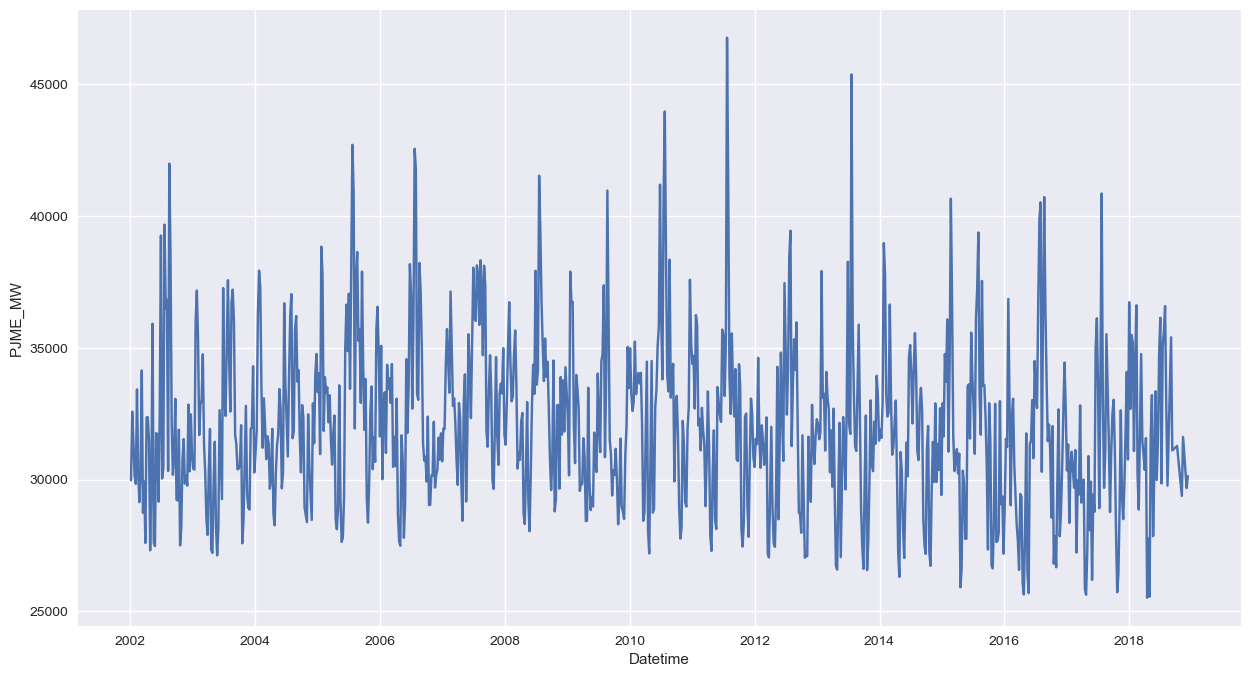

In [41]:
plt.figure(figsize=(15,8)) #haftalık olarak PJME değerlerinin nasıl göründüğüne bakalım.
sns.lineplot(y="PJME_MW" ,x='Datetime',data=df_weekly)

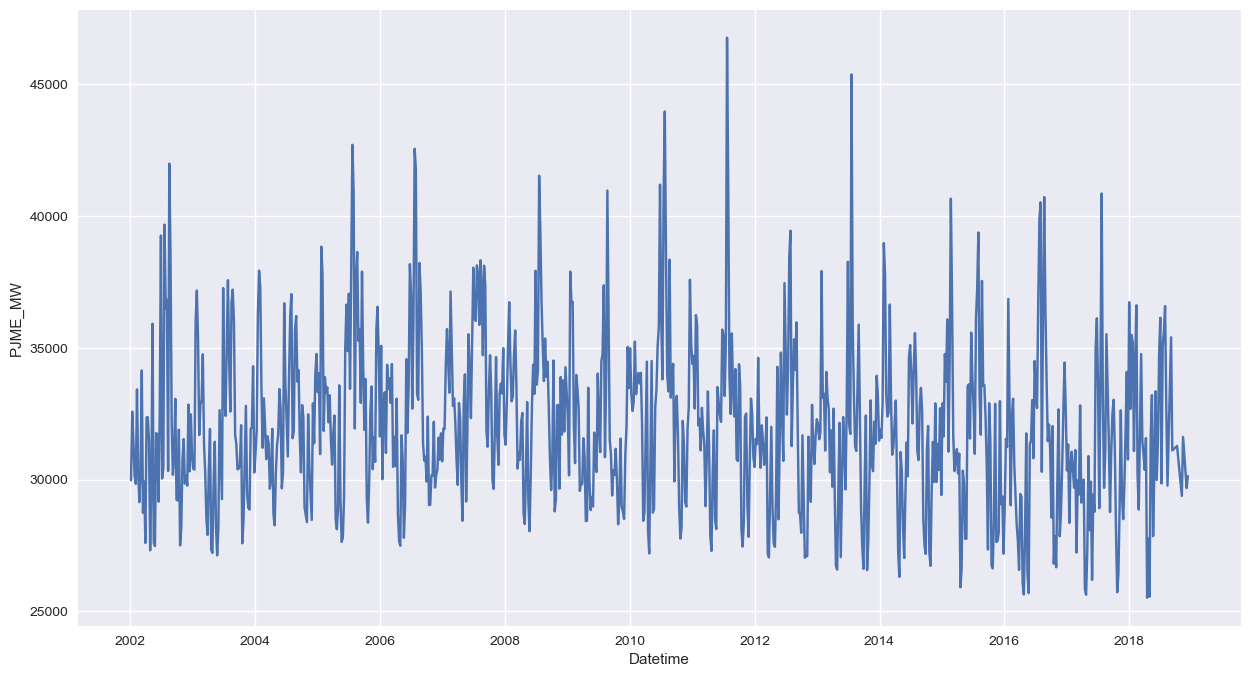

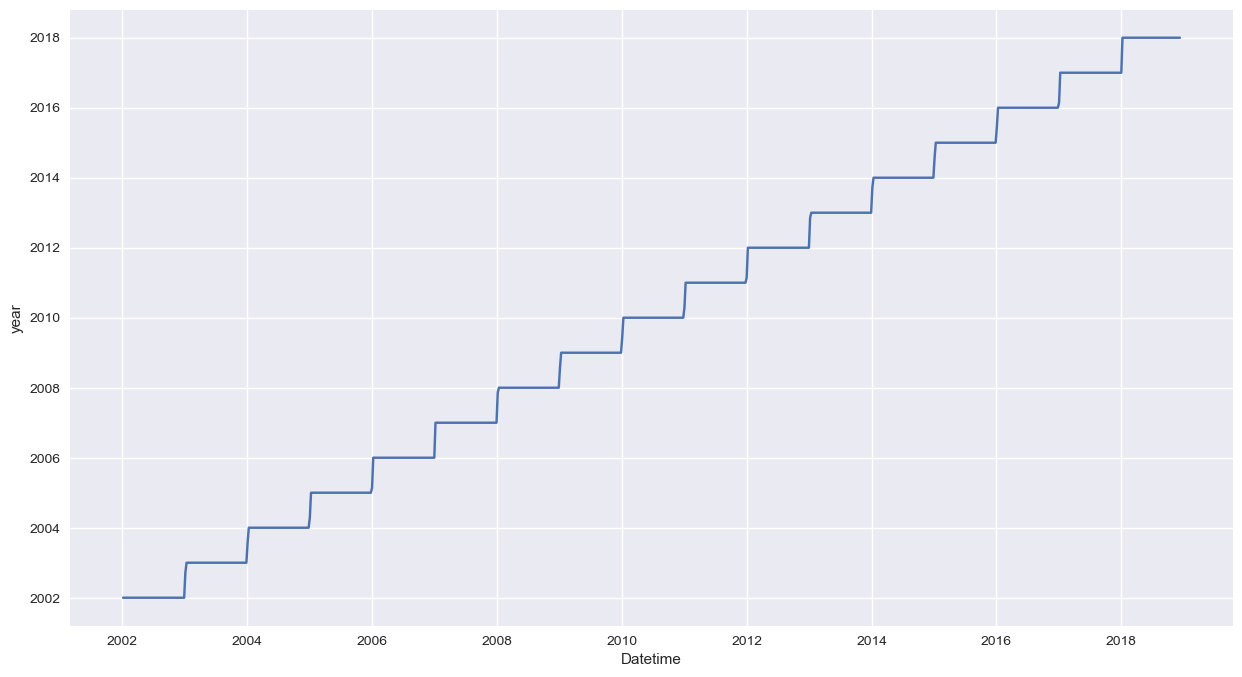

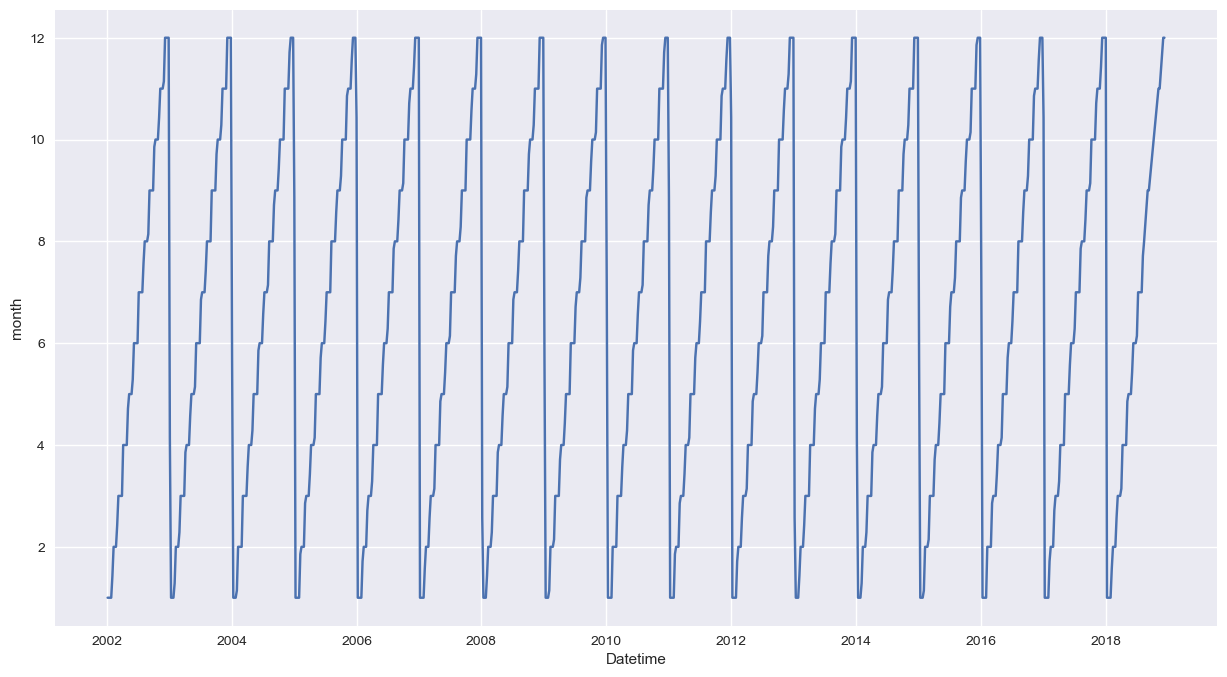

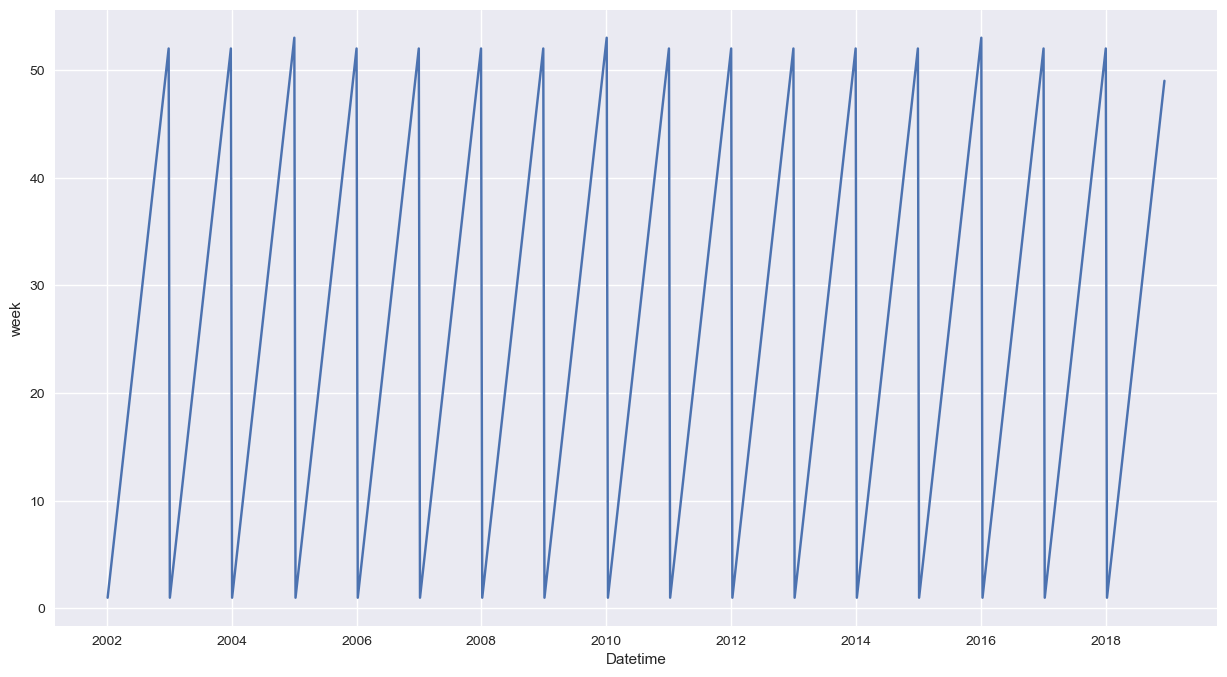

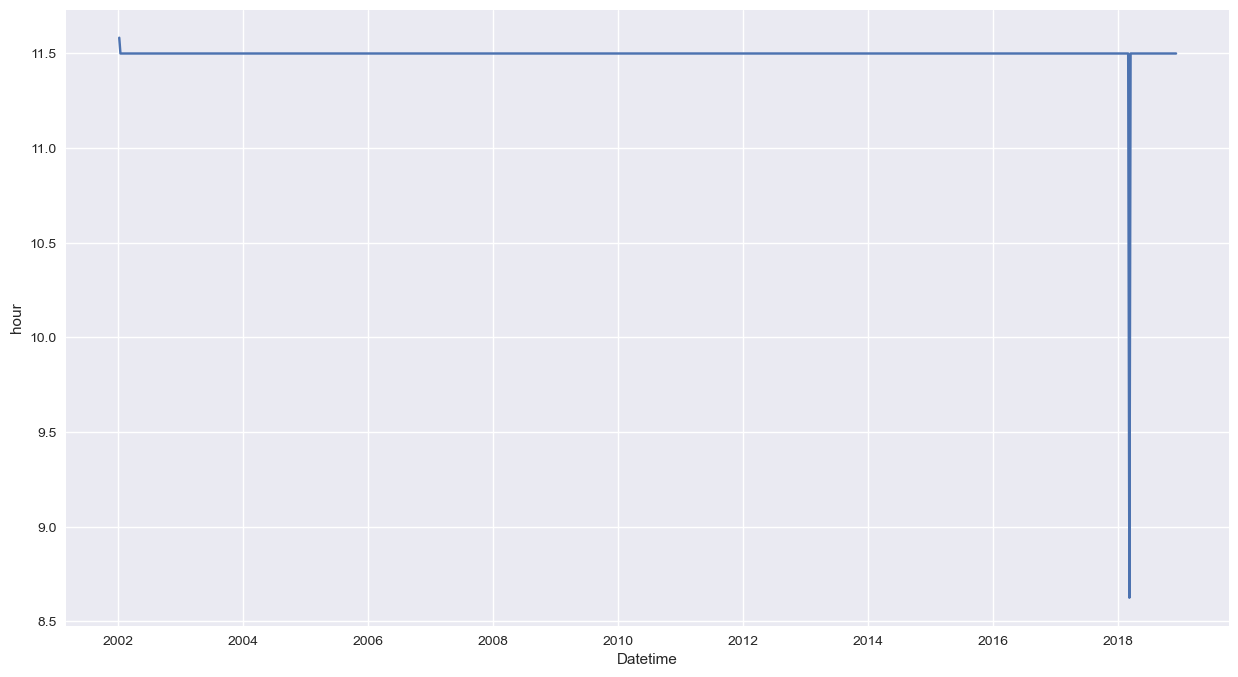

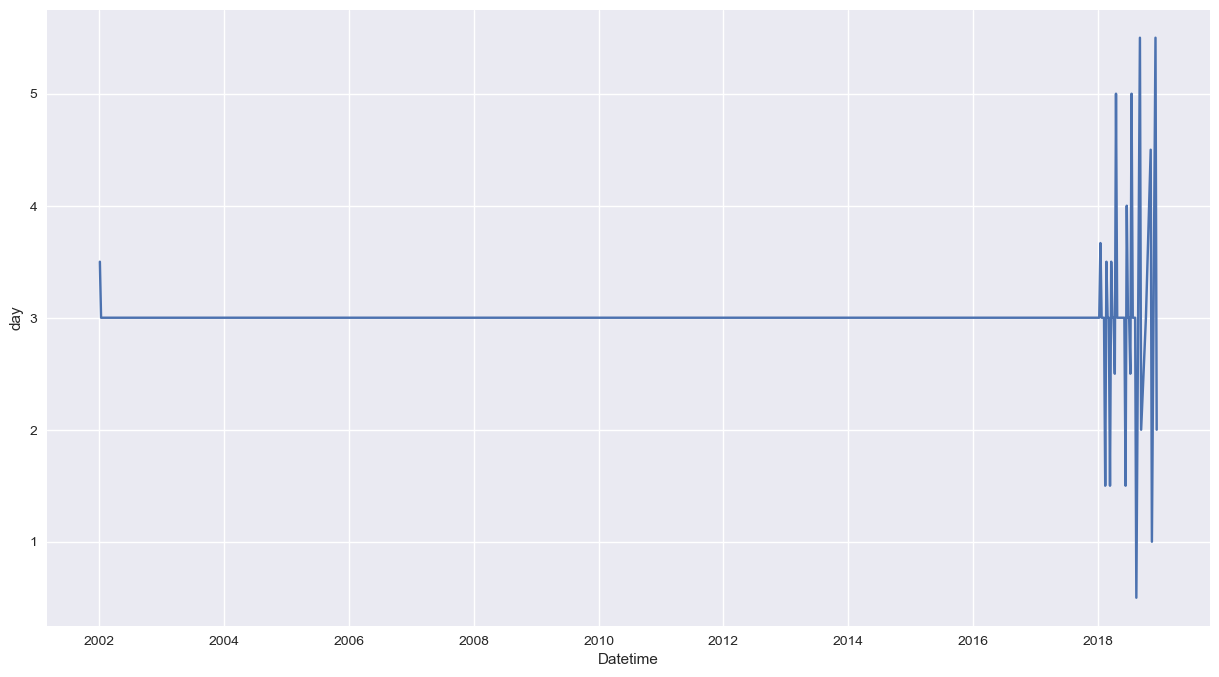

In [42]:
def plot_data(col):  #verilerimizin PJME ile olan ilişkilerini inceliyoz. ve diğer özelliklerin de yıllara göre ilişkisini inceliyelim.
    plt.figure(figsize=(15,8))
    sns.lineplot(y=col ,x='Datetime',data=df_weekly)


for col in df_weekly.columns:
    plot_data(col)

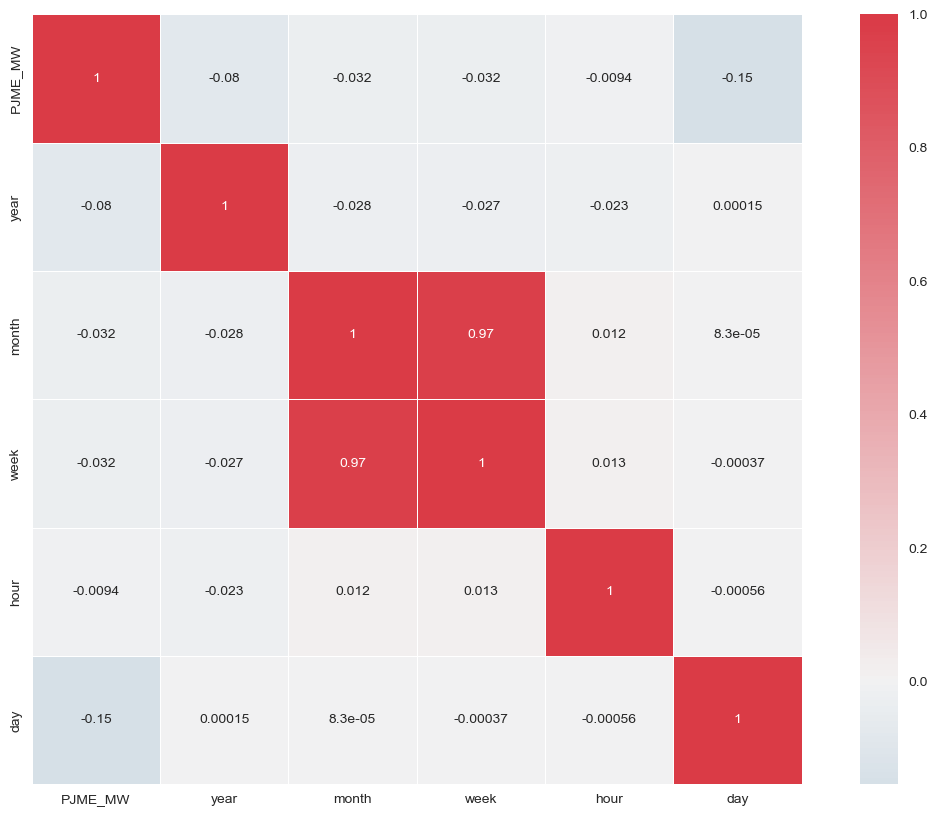

In [43]:
pollutant_corr = df_daily.corr()  # Pearson correlation--korelasyona bakıyoz ama derin öğrenmede non-linear ilişkilere baktığımız için çok gerek duymuyoz.
f, ax = plt.subplots(figsize=(15, 10))
cmap = sns.diverging_palette(240, 10, n=9, as_cmap=True)
sns.heatmap(pollutant_corr, cmap=cmap, annot=True, vmax=1, center=0,
            square=True, linewidth=.5);

## Derin Öğrenme Aşaması

In [44]:
# PARAMETERS  #derin öğrenme ile 24 saatlik geçmiş veri ile 25. saati tahmin edecez. bunun için hazır bir fonksiyon aşağıda #reframe data kısmı var.
         #bazı parametreleri tanımladık.Bunları değiştirip başarımı değiştirebiliriz.
SEED = 123
dropout_rate = 0.1
epoch = 50
batch_size = 128
return_sequence = True
target = 'PJME_MW'      #tek bir boyut aldık birden fazla da alabilirdik.
n_hours = 24          #kaç saat önceki değerleri alacağımız.
train_size = 0.8

# Aynı sonuçlar üretebilmek için--Her seferinde aynı değerleri üretebilmek için sabitleme değeri olan seed i daha önce belirlediğim seed değerine 123 eşitliyom.
os.environ['PYTHONHASHSEED']=str(SEED)  #pythonseed i eşitledim
np.random.seed(SEED)                    #numpy seed i eşitledim
random.seed(SEED)                       #random paketini eşitledim
tf.random.set_seed(SEED)                #tensorflow seed i eşitledim.
print("SEED Ayarlandı: ", SEED)

                                        #ben aşağıdaki sütunları alarak işlem yapmak istiyorum.bunları cols to analys olarak grupllandırdım.
cols_to_analyze = [      
    "PJME_MW",
    "year",
    "month",
    "week",
    "day",
    "hour"
]

SEED Ayarlandı:  123


In [45]:
# Scale data     
scaler = MinMaxScaler(feature_range=(0, 1))  #derin öğrenmede önemli olan bir adım-verileri minmaxscaler ile 0-1 arasında ölçeklendirdik.normalize ettik.
scaled_df = pd.DataFrame(scaler.fit_transform(df[cols_to_analyze]), #bu scaled df içerisine cols to analys koydukki sadece yukarıda tanımladığımız sütunlarla çalışsın.
                         index=df.index,
                         columns=cols_to_analyze)

In [46]:
scaled_df.head()  #yeni verimizin ilk satırlarını bir görelim.sadece 5 sütun ve scale 0-1 arası değerler.

,PJME_MW,year,month,week,day,hour
Datetime,,,,,,
2002-01-01 01:00:00,0.333909,0.0,0.0,0.0,0.166667,0.043478
2002-01-01 02:00:00,0.310144,0.0,0.0,0.0,0.166667,0.086957
2002-01-01 03:00:00,0.291014,0.0,0.0,0.0,0.166667,0.130435
2002-01-01 04:00:00,0.281365,0.0,0.0,0.0,0.166667,0.173913
2002-01-01 05:00:00,0.284694,0.0,0.0,0.0,0.166667,0.217391


In [47]:
# reframe data   bizim yukarıdaki çerçeve değil de geçmiş 24 saatten 25. saati sonrada geçmiş 2-25 saatten 26. saati tahmin eden bir çerçeveye ihtiyacımız var.o yuzden bu fonk kullandık.
# convert series to supervised learning
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):   #bu fonk zaman serilerini supervise learning e(gözetimli öğrenme) çeviriyor.kaç geçmiş veri n_in kaç gelecek veri n_out tan oluşacağını söyleyip bir frame leme veya çerçeveleme yapıyor.
    n_vars = 1 if type(data) is list else data.shape[1]
    df = pd.DataFrame(data)
    cols, names = list(), list()
    # input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j + 1, i)) for j in range(n_vars)]
    # forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j + 1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j + 1, i)) for j in range(n_vars)]
    # put it all together
    agg = pd.concat(cols, axis=1)
    agg.columns = names
    # drop rows with NaN values
    if dropnan:
        agg.dropna(inplace=True)
    return agg

In [48]:
#reframed diye bişey tanımladık bunun içine series to sup fonk koyduk bunun içerisinede yukarıda scale ettiğimiz scaled df koyduk 
 #bu scaled df içerisine de yukarıda cols to analys koyup hem scale etmiştik hem de sadece yukarıda tanımladığımız 5 sütunla çalışmak istiyoruz.
reframed_df = pd.DataFrame(series_to_supervised(scaled_df.to_numpy(), n_hours, len([target])))    #nhours kaç saat öne gidecez=24 target=PJME diye belirtmiştik yukarıda. tek boyut alacaz len uzunluğu.
# Düşürülecek sütunlar sondan özellik sayısından 1 eksik olana kadar gideceğiz.
reframed_df = reframed_df.iloc[:, :-(len(cols_to_analyze) - 1)]
reframed_df.index = df.index[n_hours:]

In [49]:
reframed_df

,var1(t-24),var2(t-24),var3(t-24),var4(t-24),var5(t-24),var6(t-24),var1(t-23),var2(t-23),var3(t-23),var4(t-23),...,var4(t-2),var5(t-2),var6(t-2),var1(t-1),var2(t-1),var3(t-1),var4(t-1),var5(t-1),var6(t-1),var1(t)
Datetime,,,,,,,,,,,,,,,,,,,,,
2002-02-01 01:00:00,0.333909,0.0,0.000000,0.000000,0.166667,0.043478,0.310144,0.0,0.000000,0.000000,...,0.000000,0.166667,1.000000,0.316423,0.0,0.090909,0.076923,0.666667,0.000000,0.286042
2002-02-01 02:00:00,0.310144,0.0,0.000000,0.000000,0.166667,0.086957,0.291014,0.0,0.000000,0.000000,...,0.076923,0.666667,0.000000,0.286042,0.0,0.090909,0.076923,0.666667,0.043478,0.271632
2002-02-01 03:00:00,0.291014,0.0,0.000000,0.000000,0.166667,0.130435,0.281365,0.0,0.000000,0.000000,...,0.076923,0.666667,0.043478,0.271632,0.0,0.090909,0.076923,0.666667,0.086957,0.268766
2002-02-01 04:00:00,0.281365,0.0,0.000000,0.000000,0.166667,0.173913,0.284694,0.0,0.000000,0.000000,...,0.076923,0.666667,0.086957,0.268766,0.0,0.090909,0.076923,0.666667,0.130435,0.273654
2002-02-01 05:00:00,0.284694,0.0,0.000000,0.000000,0.166667,0.217391,0.297272,0.0,0.000000,0.000000,...,0.076923,0.666667,0.130435,0.273654,0.0,0.090909,0.076923,0.666667,0.173913,0.292026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-02-08 20:00:00,0.681934,1.0,0.000000,0.019231,0.000000,0.869565,0.662404,1.0,0.000000,0.019231,...,0.096154,0.500000,0.782609,0.655156,1.0,0.090909,0.096154,0.500000,0.826087,0.621784
2018-02-08 21:00:00,0.662404,1.0,0.000000,0.019231,0.000000,0.913043,0.622564,1.0,0.000000,0.019231,...,0.096154,0.500000,0.826087,0.621784,1.0,0.090909,0.096154,0.500000,0.869565,0.604909
2018-02-08 22:00:00,0.622564,1.0,0.000000,0.019231,0.000000,0.956522,0.550342,1.0,0.000000,0.019231,...,0.096154,0.500000,0.869565,0.604909,1.0,0.090909,0.096154,0.500000,0.913043,0.569009


In [50]:
# split_data
X = reframed_df.iloc[:, :-1]  #girdi değişkeni, sadece son sütunu almayacak
y = reframed_df.iloc[:, -1]   #çıktı değişkeni, sadece son sütunu alacak
print(X.shape, "x", y.shape, "y")  #x ve y şeklinde yazdırdık. sonuçta x değişkeni 120 sütun, boyuttan ve 145368 satırdan oluşuyor.y de tek boyutlu değer.

(145368, 144) x (145368,) y


In [51]:
df.shape #yukarıdaki 145368 df den 145392 ten niye farklı 24 eksik. çünkü 24 saatlik veriyi almadık

(145392, 8)

In [52]:
X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(X, y, train_size=train_size, shuffle=False)  ##train ve test setlerine ihtiyacımız var. bunun için tra test spl fonk kullandık.train size % 80 olrk yukarıda belirttik.shuffle yani karıştırma false yani iptal.çünkü zaman serisi.
X_train = X_train_df.to_numpy().reshape((X_train_df.shape[0], n_hours, scaled_df.shape[1]))  ##xtrain ve ytrain i bir donuşume sokuyoz. çunku lstm 3 boyuta göre çalışıyor bu iki boyutu 3 boyuta çıkarıyoz.
X_test = X_test_df.to_numpy().reshape((X_test_df.shape[0], n_hours, scaled_df.shape[1]))    ##xtrain test satır sayısı, nhours sütun sayısı ve scaled df 120 olan sütun sayısını da 3. boyut olarak aldık

In [53]:
X_train.shape, y_train_df.shape, X_test.shape, y_test_df.shape  #116273 satır 24 sütundan oluşuyor ve bunlardan 5 tane var.aşağıda satır sayılarının aynı olduğu görülüyor.

((116294, 24, 6), (116294,), (29074, 24, 6), (29074,))

In [56]:
import tensorflow as tf
from tensorflow import keras
from keras import optimizers #sonradan eklendi
#import torch.optim as optim  #adamW içindi

In [58]:
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))
optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=False)
model.compile(optimizer=optimizer, loss='mse', metrics=['accuracy'])

In [59]:
#fit model
history = model.fit(X_train,
                    y_train_df.to_numpy(),
                    epochs=epoch,
                    batch_size=batch_size,
                    validation_data=(X_test, y_test_df.to_numpy()),
                    verbose=1,
                    shuffle=False)  #fit fonk ile bunu çalıştırmışız. dikkat etmemiz gereken girdiyi x-tr ve çıktıyı y-tr birlikte veriyoruz daha sonrada validation u içinde veriyoruz. burda bizim ayırdığımız testi val seti olarak verebiliriz.verbose 1 yani yazdır diyoruz.

Epoch 1/50
909/909 [==============================] - 30s 33ms/step - loss: 0.0097 - accuracy: 1.7198e-05 - val_loss: 0.0054 - val_accuracy: 0.0000e+00
Epoch 2/50
909/909 [==============================] - 28s 31ms/step - loss: 0.0027 - accuracy: 1.7198e-05 - val_loss: 0.0018 - val_accuracy: 0.0000e+00
Epoch 3/50
909/909 [==============================] - 28s 31ms/step - loss: 0.0013 - accuracy: 1.7198e-05 - val_loss: 0.0010 - val_accuracy: 0.0000e+00
Epoch 4/50
909/909 [==============================] - 29s 31ms/step - loss: 5.9684e-04 - accuracy: 1.7198e-05 - val_loss: 6.7242e-04 - val_accuracy: 0.0000e+00
Epoch 5/50
909/909 [==============================] - 29s 32ms/step - loss: 3.4981e-04 - accuracy: 1.7198e-05 - val_loss: 4.8541e-04 - val_accuracy: 0.0000e+00
Epoch 6/50
909/909 [==============================] - 30s 33ms/step - loss: 2.5570e-04 - accuracy: 1.7198e-05 - val_loss: 2.8901e-04 - val_accuracy: 0.0000e+00
Epoch 7/50
909/909 [==============================] - 30s 33ms/s

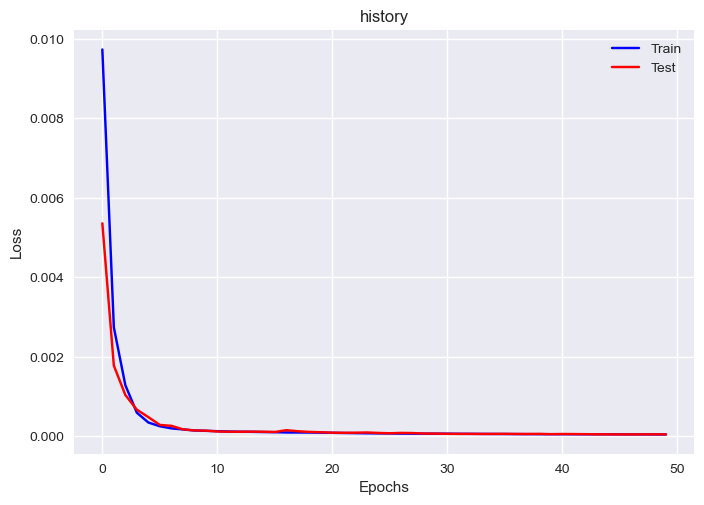

In [60]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(len(loss))
plt.figure()
plt.plot(epochs, loss, "b", label="Train")
plt.plot(epochs, val_loss, "r", label="Test")
plt.title("history")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [61]:
##geleceğe dair veya test değerlerine dair birtakım tahmin değerlerine ihtiyacımız var. 
##bunun içinde verilerimizi eski haline yani minmaxscale edilmemiş haline getirmemiz inversscale etmemiz gerekiyor.
scaler_pred = MinMaxScaler()
scaler_pred.fit(df[target].to_numpy().reshape(-1, 1))       ##bunun için yeni bir scaler tanımlayıp target la fit ettik, uyumlu hale getirdik 
y_pred_test = model.predict(X_test)                         # yhat tahmin değerleri y_test ler ile kıyaslanacak.        ##ve daha sonra x_test i tahmin ettik.y_predtest bizim x_test e karşılık gelecek veya kıyaslama yapacağımız değerler.
# inverse scaling for forecast
inv_y_pred_test = scaler_pred.inverse_transform(y_pred_test)      ##daha sonra burda inv_y_predtest i invers transform un içine koyarak artık y_test lerimiz gerçek değerler oldu.
y_true_test = scaler_pred.inverse_transform(y_test_df.to_numpy().reshape(-1, 1))                                                       ##y_true test de gerçek değerlerimizi sembolize ediyor. biz bunun shape ini değiştirerek kaydediyoruz. 
# make predictions (train)
y_pred_train = model.predict(X_train)  # yhat tahmin değerleri y_test ler ile kıyaslanacak. ##daha sonrada y_pred train le x_train i tahmin ederek kaydettik ki hem train performansına hem test performansına ulaşmak istiyorum. bunun için de aşağıdaki gibi değişkenler tanımladık.
# inverse scaling for forecast
inv_y_pred_train = scaler_pred.inverse_transform(y_pred_train)
y_true_train = scaler_pred.inverse_transform(y_train_df.to_numpy().reshape(-1, 1))

In [62]:
#bunun sonucunda tabiki biz daha az hataya ulaşmak isteriz. daha az hatanın farklı performans ölçütleri var ama biz bunların rmse ve mae sine bakacaz.
#test setinin, x_test ve y_test in rmse ve mae sine ulaşmak istiyorum
# TEST
test_R2 = r2_score(inv_y_pred_test, y_true_test)
test_rmse = mean_squared_error(inv_y_pred_test, y_true_test, squared=False)
test_mae = mean_absolute_error(inv_y_pred_test, y_true_test)

In [63]:
test_rmse

339.336148385229

In [64]:
test_mae

242.5471784417564

In [65]:
test_R2

0.9972926656366602

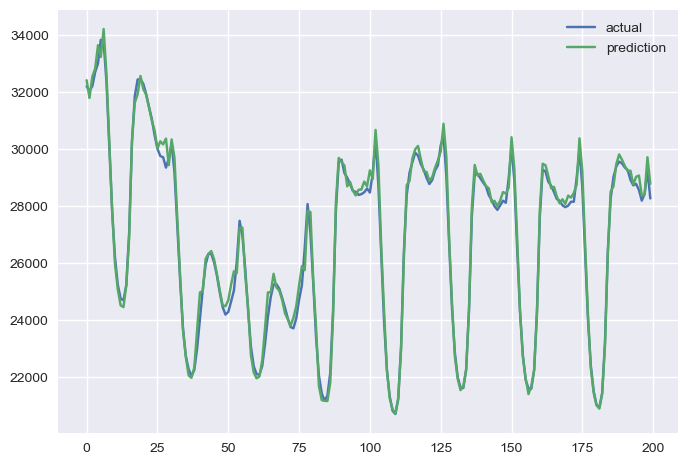

In [66]:
#peki biz bu tahmin sonucunda verilerimizin uyup uymadığını görmek istersek:
#[:200] yazmazsak 
#plt.plot(y_true_test) 
#plt.plot(inv_y_pred_test)
#plt.savefig("cikti.svg")
#yazarsak tüm değerleri verir ve başka yerde büyütebiliriz.
plt.plot(y_true_test[:200], label="actual")    #sığsın diye ilk 200 veriyi görmeye çalışalımki grafik daha okunaklı olsun. actual gerçek prediction tahmin değerler.
plt.plot(inv_y_pred_test[:200], label="prediction")
plt.legend()   #bunları göster.

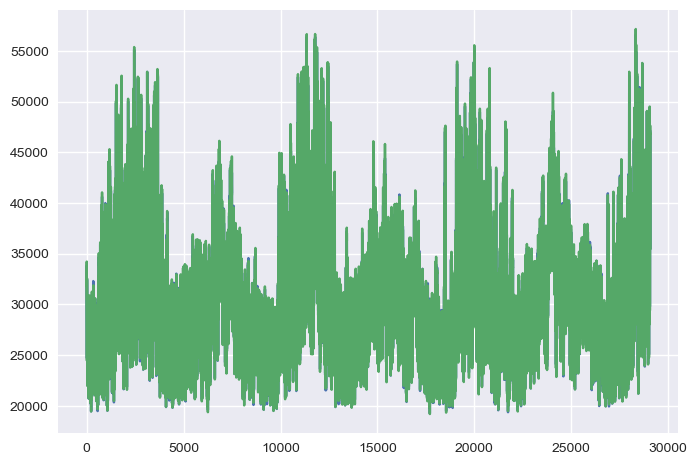

In [67]:
plt.plot(y_true_test) 
plt.plot(inv_y_pred_test)
plt.savefig("cikti.svg")

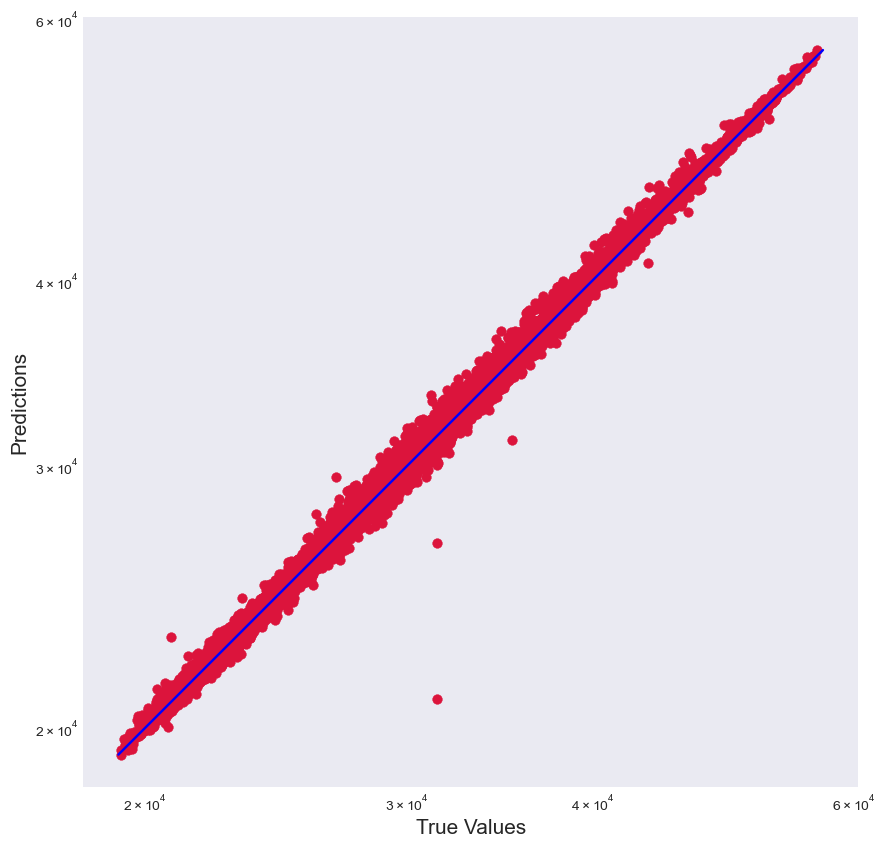

In [68]:
#bir diğer grafiğimiz ise regresyon grafiği olarak geçer.gerçek veriler ile tahmin verilerimiz ne kadar uyuşmuş aşağıdaki mavi çizgi üzerinde göstermek istersek.
#bazı veriler doğru tahmin edilememiş bazı veriler tahmin edilmiş ama burda çizgiye yakın bir yoğunlaşmadan bahsedebildiğimiz için iyi bir tahmin gerçekleşmiş diyebiliriz.
# train_test train için mi test için mi
plt.figure(figsize=(10, 10))
plt.scatter(y_true_test, inv_y_pred_test, c='crimson')
plt.yscale('log')
plt.xscale('log')
p1 = max(max(inv_y_pred_test), max(y_true_test))
p2 = min(min(inv_y_pred_test), min(y_true_test))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
#plt.savefig("images/true_preds{}_{}.jpg".format(model_number, train_test))
plt.show()